# Introduction to Matplotlib for Beginning Python Users

This notebook introduces the main ideas you need to start making plots with Matplotlib.

Topics covered:
- figures and axes
- axis labels and titles
- larger default font sizes
- legends
- side-by-side subplots
- 1D histograms
- histogram options and histogram error bars
- 2D histograms
- scatter plots and error bars
- log scales
- customizing colors, markers, and line styles
- annotations and text
- subplot layouts and shared axes
- saving figures to files

The examples are written for beginners and are heavily commented.


## 1. Import the libraries

Matplotlib is the plotting library.
NumPy helps us create arrays of numbers and simulated data.


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed so that the random data is reproducible.
np.random.seed(42)


## 2. Figures and axes

A **figure** is the whole plotting window.
An **axes** object is the part of the figure where the data is drawn.

You will very often use:

```python
fig, ax = plt.subplots()
```


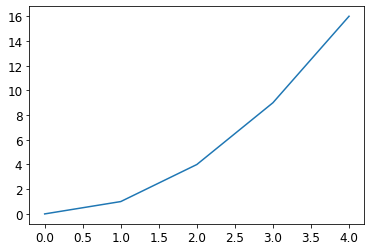

In [13]:
# Create a figure and a single axes.
fig, ax = plt.subplots(figsize=(6, 4))

# Create some very simple data.
x_simple = np.array([0, 1, 2, 3, 4])
y_simple = np.array([0, 1, 4, 9, 16])

# Plot the data on the axes.
ax.plot(x_simple, y_simple)

plt.show()


## 3. Axis labels and titles

Good plots should make it obvious what is plotted.
Axis labels and titles are essential for that.


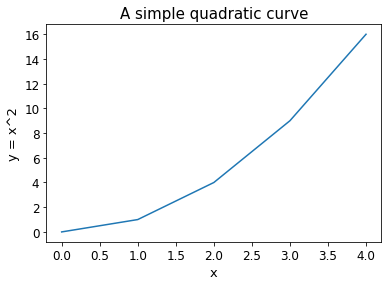

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_simple, y_simple, color="tab:blue")

ax.set_xlabel("x")
ax.set_ylabel("y = x^2")
ax.set_title("A simple quadratic curve")

plt.show()


### Make Text More Readable

Matplotlib's default text can be too small.
It is often worth setting larger defaults early in your notebook.


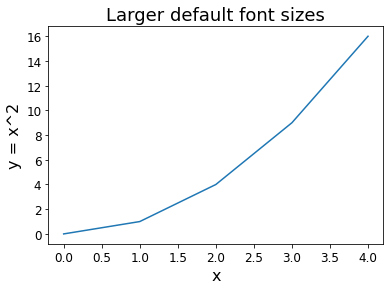

In [17]:
# Increase default text sizes to improve readability.
plt.rcParams["font.size"] = 16
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12

# Quick check of the larger font settings.
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_simple, y_simple)
ax.set_xlabel("x")
ax.set_ylabel("y = x^2")
ax.set_title("Larger default font sizes")
plt.show()


## 4. Legends

Legends explain which plotted object corresponds to which data series.
To use one, give each plotted object a `label` and then call `ax.legend()`.


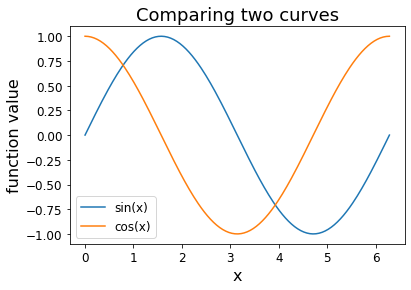

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))

x_wave = np.linspace(0, 2 * np.pi, 200)
y_sin = np.sin(x_wave)
y_cos = np.cos(x_wave)

ax.plot(x_wave, y_sin, label="sin(x)", color="tab:blue")
ax.plot(x_wave, y_cos, label="cos(x)", color="tab:orange")

ax.set_xlabel("x")
ax.set_ylabel("function value")
ax.set_title("Comparing two curves")
ax.legend()

plt.show()


## 5. Side-by-side plots with `subplots`

A common task is to show more than one plot in the same figure.
Two useful layouts are `2 x 1` and `2 x 2`.


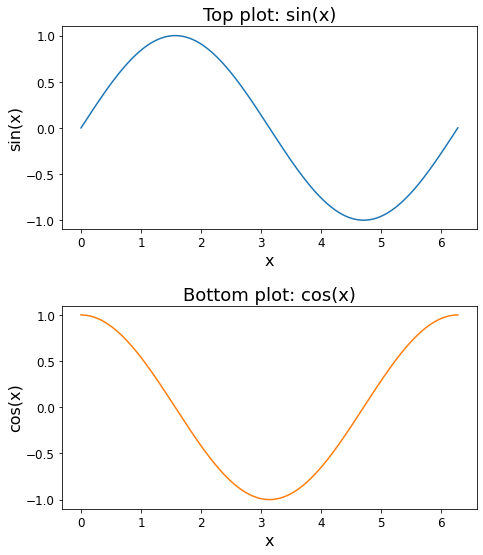

In [19]:
# Example of a 2 x 1 layout: two rows and one column.
fig, axes = plt.subplots(2, 1, figsize=(7, 8))

axes[0].plot(x_wave, np.sin(x_wave), color="tab:blue")
axes[0].set_title("Top plot: sin(x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("sin(x)")

axes[1].plot(x_wave, np.cos(x_wave), color="tab:orange")
axes[1].set_title("Bottom plot: cos(x)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("cos(x)")

fig.tight_layout()
plt.show()


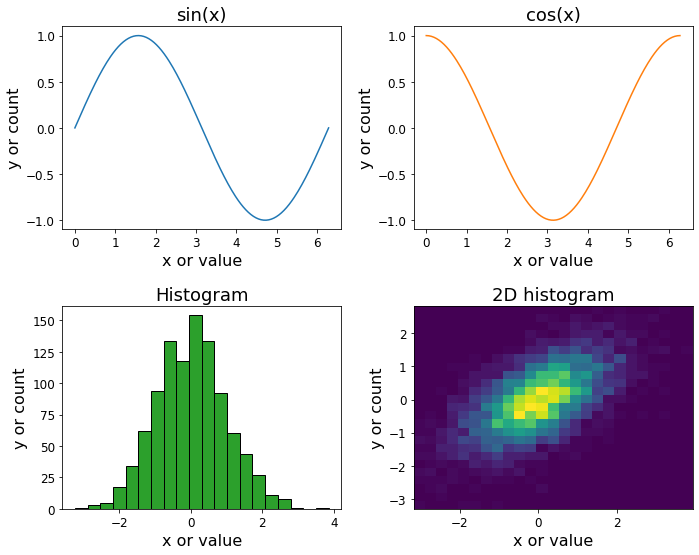

In [20]:
# Create some sample data for the 2 x 2 example.
sample = np.random.normal(loc=0.0, scale=1.0, size=1000)
x2 = np.random.normal(size=5000)
y2 = 0.5 * x2 + np.random.normal(scale=0.7, size=5000)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].plot(x_wave, np.sin(x_wave), color="tab:blue")
axes[0, 0].set_title("sin(x)")

axes[0, 1].plot(x_wave, np.cos(x_wave), color="tab:orange")
axes[0, 1].set_title("cos(x)")

axes[1, 0].hist(sample, bins=20, color="tab:green", linewidth=0)
axes[1, 0].set_title("Histogram")

axes[1, 1].hist2d(x2, y2, bins=25, cmap="viridis")
axes[1, 1].set_title("2D histogram")

for ax in axes.ravel():
    ax.set_xlabel("x or value")
    ax.set_ylabel("y or count")

fig.tight_layout()
plt.show()


## 6. 1D histograms

A histogram shows how values are distributed.
The height of each bin tells you how many entries fall into that bin.


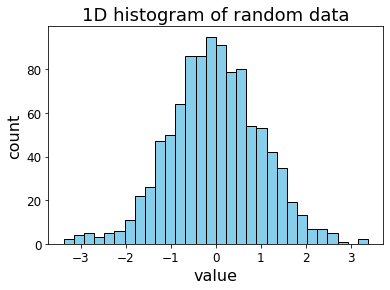

In [21]:
sample = np.random.normal(loc=0.0, scale=1.0, size=1000)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(sample, bins=30, color="skyblue", linewidth=0)
ax.set_xlabel("value")
ax.set_ylabel("count")
ax.set_title("1D histogram of random data")
plt.show()


## 7. Different histogram plotting options

Matplotlib histograms support several useful options.

Common ones include:
- `bins`: number of bins or exact bin edges
- `density=True`: normalize so the area is 1
- `histtype`: choose how the histogram is drawn
- `alpha`: transparency
- `edgecolor`: color of bin edges


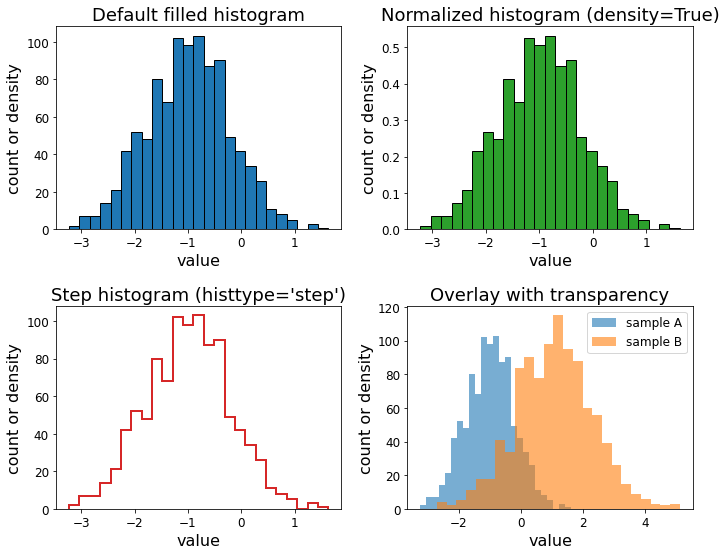

In [22]:
sample_a = np.random.normal(loc=-1.0, scale=0.8, size=1000)
sample_b = np.random.normal(loc=1.0, scale=1.2, size=1000)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(sample_a, bins=25, color="tab:blue", linewidth=0)
axes[0, 0].set_title("Default filled histogram")

axes[0, 1].hist(sample_a, bins=25, density=True, color="tab:green", linewidth=0)
axes[0, 1].set_title("Normalized histogram (density=True)")

axes[1, 0].hist(sample_a, bins=25, histtype="step", linewidth=2, color="tab:red")
axes[1, 0].set_title("Step histogram (histtype='step')")

axes[1, 1].hist(sample_a, bins=25, alpha=0.6, label="sample A")
axes[1, 1].hist(sample_b, bins=25, alpha=0.6, label="sample B")
axes[1, 1].set_title("Overlay with transparency")
axes[1, 1].legend()

for ax in axes.ravel():
    ax.set_xlabel("value")
    ax.set_ylabel("count or density")

fig.tight_layout()
plt.show()


### Histogram with statistical error bars

Sometimes you want to show the uncertainty in each histogram bin.
For simple counting data, a common estimate is:

$$\sigma_N = \sqrt{N}$$

where `N` is the number of entries in the bin.


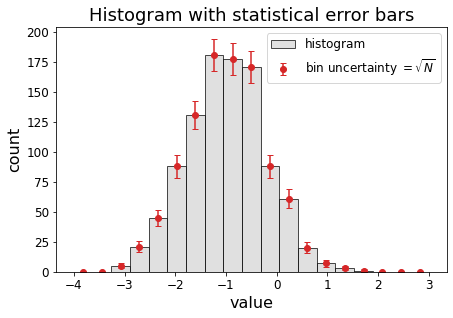

In [23]:
bin_edges = np.linspace(-4, 3, 20)
counts, edges = np.histogram(sample_a, bins=bin_edges)
bin_centers = 0.5 * (edges[:-1] + edges[1:])
count_errors = np.sqrt(counts)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(sample_a, bins=bin_edges, color="lightgray", alpha=0.7, linewidth=0, label="histogram")
ax.errorbar(
    bin_centers,
    counts,
    yerr=count_errors,
    fmt="o",
    color="tab:red",
    capsize=3,
    label=r"bin uncertainty $= \sqrt{N}$",
)
ax.set_xlabel("value")
ax.set_ylabel("count")
ax.set_title("Histogram with statistical error bars")
ax.legend()
plt.show()


## 8. 2D histograms

A 2D histogram counts how often values fall into bins in **two dimensions**.
This is useful when you want to study how two variables are related.


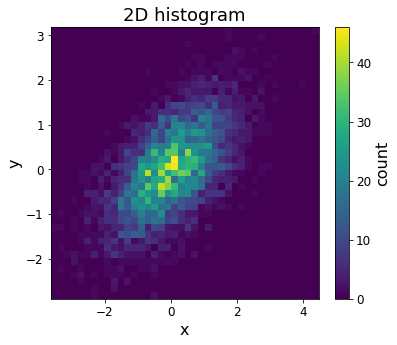

In [24]:
x2 = np.random.normal(size=5000)
y2 = 0.5 * x2 + np.random.normal(scale=0.7, size=5000)

fig, ax = plt.subplots(figsize=(6, 5))
hist = ax.hist2d(x2, y2, bins=40, cmap="viridis")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("2D histogram")
fig.colorbar(hist[3], ax=ax, label="count")
plt.show()


## 9. Scatter plots and error bars

Scatter plots show individual points.
Error bars are useful when your points have uncertainties.


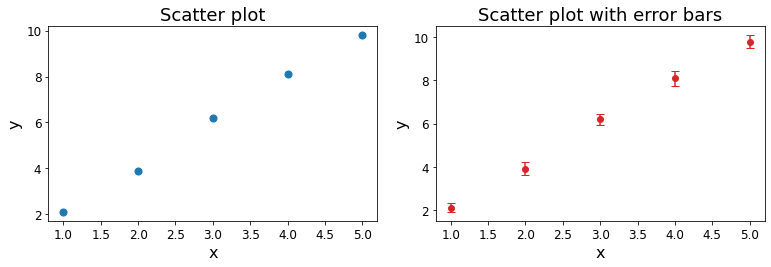

In [25]:
x_points = np.array([1, 2, 3, 4, 5])
y_points = np.array([2.1, 3.9, 6.2, 8.1, 9.8])
y_errors = np.array([0.2, 0.3, 0.25, 0.35, 0.3])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Plain scatter plot.
axes[0].scatter(x_points, y_points, color="tab:blue", s=50)
axes[0].set_title("Scatter plot")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Scatter plot with vertical error bars.
axes[1].errorbar(
    x_points,
    y_points,
    yerr=y_errors,
    fmt="o",
    color="tab:red",
    capsize=4,
)
axes[1].set_title("Scatter plot with error bars")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

fig.tight_layout()
plt.show()


## 10. Log scales

Sometimes your data spans many orders of magnitude.
In those cases, a logarithmic axis can be much more useful than a linear one.

Use:
- `ax.set_xscale("log")`
- `ax.set_yscale("log")`


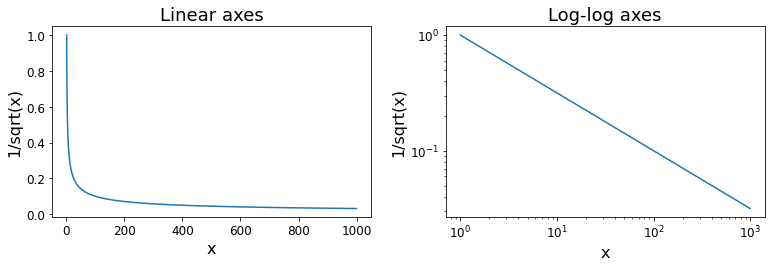

In [26]:
x_log = np.linspace(0, 10, 200)
decay_constant = 2.0
y_log = np.exp(-x_log / decay_constant)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(x_log, y_log)
axes[0].set_title("Exponential decay on linear axes")
axes[0].set_xlabel("x")
axes[0].set_ylabel("exp(-x / 2)")

axes[1].plot(x_log, y_log)
axes[1].set_yscale("log")
axes[1].set_title("Same data with a log y-axis")
axes[1].set_xlabel("x")
axes[1].set_ylabel("exp(-x / 2)")

fig.tight_layout()
plt.show()


## 11. Customizing colors, markers, and line styles

Matplotlib lets you control how a plot looks.
Useful options include:
- `color`
- `marker`
- `linestyle`
- `linewidth`
- `markersize`


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    x_wave,
    np.sin(x_wave),
    color="purple",
    marker="o",
    linestyle="--",
    linewidth=2,
    markersize=4,
    label="custom line",
)

ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
ax.set_title("Custom colors, markers, and line styles")
ax.legend()
plt.show()


## 12. Annotations and text on plots

Annotations are useful when you want to call attention to a point or region.
You can also place free text directly on the axes.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_wave, np.sin(x_wave), color="tab:blue")

# Annotate the point near pi/2 where sin(x) is close to 1.
ax.annotate(
    "maximum",
    xy=(np.pi / 2, 1.0),
    xytext=(2.2, 0.7),
    arrowprops={"arrowstyle": "->", "color": "black"},
)

# Add free text inside the plot.
ax.text(4.2, -0.8, "Example text inside the axes")

ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
ax.set_title("Annotations and text")
plt.show()


## 13. Subplot layouts and shared axes

When several plots use the same x-axis or y-axis, shared axes can make the figure easier to read.
Use `sharex=True` or `sharey=True` inside `plt.subplots(...)`.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

axes[0].plot(x_wave, np.sin(x_wave), color="tab:blue")
axes[0].set_ylabel("sin(x)")
axes[0].set_title("Shared x-axis example")

axes[1].plot(x_wave, np.cos(x_wave), color="tab:orange")
axes[1].set_xlabel("x")
axes[1].set_ylabel("cos(x)")

fig.tight_layout()
plt.show()


## 14. Suggested next topics

Good follow-up topics to cover after this notebook:
- plotting directly from pandas DataFrames
- bar charts and box plots
- controlling tick marks and tick labels
- colormaps and color bars in more detail
- figure-wide labels and super-titles
- exporting publication-quality figures

A good exercise is to take one plot from this notebook and restyle it in three different ways.


## 15. Saving figures to files

Matplotlib can save figures in many file formats.
Common examples are PNG, PDF, and SVG.

You can save using either:
- `fig.savefig(...)`
- `plt.savefig(...)`

Using `fig.savefig(...)` is usually clearer because it saves a specific figure object.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_wave, np.sin(x_wave), label="sin(x)", color="tab:blue")
ax.plot(x_wave, np.cos(x_wave), label="cos(x)", color="tab:orange")
ax.set_xlabel("x")
ax.set_ylabel("function value")
ax.set_title("Figure saved in multiple formats")
ax.legend()

# Save the figure with fig.savefig(...).
fig.savefig("matplotlib_example_plot.png", dpi=150, bbox_inches="tight")
fig.savefig("matplotlib_example_plot.pdf", bbox_inches="tight")
fig.savefig("matplotlib_example_plot.svg", bbox_inches="tight")

# plt.savefig(...) also works and saves the current figure.
plt.savefig("matplotlib_example_plot_copy.png", dpi=150, bbox_inches="tight")

plt.show()

print("Saved files:")
print("- matplotlib_example_plot.png")
print("- matplotlib_example_plot.pdf")
print("- matplotlib_example_plot.svg")
print("- matplotlib_example_plot_copy.png")
